In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE = '/kaggle/input/datasets/elisabethwilliam/urbanev-shenzhen-zone'

# Load core data
occupancy = pd.read_csv(f'{BASE}/occupancy.csv',  index_col=0, parse_dates=True)
weather   = pd.read_csv(f'{BASE}/weather_airport.csv')
e_price   = pd.read_csv(f'{BASE}/e_price.csv',    index_col=0, parse_dates=True)

# Parse datetime index explicitly
occupancy.index = pd.to_datetime(occupancy.index)
e_price.index   = pd.to_datetime(e_price.index)

# Zone list
occ_zones = [int(c) for c in occupancy.columns]

print(f"Occupancy shape: {occupancy.shape}")
print(f"Weather shape:   {weather.shape}")
print(f"E-price shape:   {e_price.shape}")
print(f"Zones:           {len(occ_zones)}")
print(f"Time range:      {occupancy.index[0]} → {occupancy.index[-1]}")
print("\nWeather columns:", weather.columns.tolist())

Occupancy shape: (4344, 275)
Weather shape:   (4344, 7)
E-price shape:   (4344, 275)
Zones:           275
Time range:      2022-09-01 00:00:00 → 2023-02-28 23:00:00

Weather columns: ['time', 'T', 'P0', 'P', 'U', 'nRAIN', 'Td']


**Feature Matrix & train/test split**

In [2]:
# ── Temporal features ─────────────────────────────────────────────────────────
time_index = occupancy.index

hour       = time_index.hour
dow        = time_index.dayofweek
month      = time_index.month

temporal = pd.DataFrame({
    'hour_sin':   np.sin(2 * np.pi * hour / 24),
    'hour_cos':   np.cos(2 * np.pi * hour / 24),
    'dow_sin':    np.sin(2 * np.pi * dow / 7),
    'dow_cos':    np.cos(2 * np.pi * dow / 7),
    'month_sin':  np.sin(2 * np.pi * month / 12),
    'month_cos':  np.cos(2 * np.pi * month / 12),
    'is_weekend': (dow >= 5).astype(int),
    'is_peak':    hour.isin([7,8,9,17,18,19,20]).astype(int),
}, index=time_index)

# ── Weather features ──────────────────────────────────────────────────────────
weather.index = time_index
weather_feats = weather[['T', 'U', 'nRAIN', 'Td']].copy()
weather_feats.columns = ['temp', 'humidity', 'rainfall', 'dewpoint']

# ── Mean e-price across zones (single signal) ─────────────────────────────────
mean_price = e_price.mean(axis=1).rename('mean_eprice')

# ── Combine all exogenous features ────────────────────────────────────────────
exog = pd.concat([temporal, weather_feats, mean_price], axis=1)

print(f"Exogenous features shape: {exog.shape}")
print(f"Features: {exog.columns.tolist()}")

# ── Train / Validation / Test split (70 / 15 / 15) ───────────────────────────
n = len(occupancy)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

occ_train = occupancy.iloc[:train_end]
occ_val   = occupancy.iloc[train_end:val_end]
occ_test  = occupancy.iloc[val_end:]

exog_train = exog.iloc[:train_end]
exog_val   = exog.iloc[train_end:val_end]
exog_test  = exog.iloc[val_end:]

print(f"\nTrain:      {len(occ_train)} timesteps ({occ_train.index[0].date()} → {occ_train.index[-1].date()})")
print(f"Validation: {len(occ_val)}  timesteps ({occ_val.index[0].date()} → {occ_val.index[-1].date()})")
print(f"Test:       {len(occ_test)}  timesteps ({occ_test.index[0].date()} → {occ_test.index[-1].date()})")

Exogenous features shape: (4344, 13)
Features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_peak', 'temp', 'humidity', 'rainfall', 'dewpoint', 'mean_eprice']

Train:      3040 timesteps (2022-09-01 → 2023-01-05)
Validation: 652  timesteps (2023-01-05 → 2023-02-01)
Test:       652  timesteps (2023-02-01 → 2023-02-28)


**Normalising occupancy and build XGBoost feature matrix**

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Normalise occupancy (0-1) — fit on train only
occ_scaler = MinMaxScaler()
occ_train_scaled = occ_scaler.fit_transform(occ_train)
occ_val_scaled   = occ_scaler.transform(occ_val)
occ_test_scaled  = occ_scaler.transform(occ_test)

print("Occupancy normalised.")
print(f"Train range: {occ_train_scaled.min():.3f} – {occ_train_scaled.max():.3f}")

# For XGBoost: predict mean occupancy across all zones (system-level baseline)
#  per-zone after
y_train = occ_train_scaled.mean(axis=1)
y_val   = occ_val_scaled.mean(axis=1)
y_test  = occ_test_scaled.mean(axis=1)

# XGBoost feature matrix: exog + lagged mean occupancy (1h, 24h, 168h)
mean_occ_full = pd.Series(occ_train_scaled.mean(axis=1),
                           index=occ_train.index)

def build_xgb_features(exog_df, occ_series, lags=[1, 24, 168]):
    X = exog_df.copy()
    for lag in lags:
        X[f'occ_lag_{lag}h'] = occ_series.shift(lag)
    return X.dropna()

# Build mean occupancy series from full scaled occupancy
full_occ_scaled = occ_scaler.transform(occupancy)
mean_occ_series = pd.Series(
    full_occ_scaled.mean(axis=1),
    index=occupancy.index
)

# Build XGBoost feature matrix using lagged mean occupancy
def build_xgb_features(exog_df, occ_series, lags=[1, 24, 168]):
    X = exog_df.copy()
    for lag in lags:
        X[f'occ_lag_{lag}h'] = occ_series.shift(lag)
    return X.dropna()

X_train_xgb = build_xgb_features(exog_train, mean_occ_series.loc[exog_train.index])
y_train_xgb = mean_occ_series.loc[X_train_xgb.index]

X_val_xgb   = build_xgb_features(exog_val, mean_occ_series.loc[exog_val.index])
y_val_xgb   = mean_occ_series.loc[X_val_xgb.index]

X_test_xgb  = build_xgb_features(exog_test, mean_occ_series.loc[exog_test.index])
y_test_xgb  = mean_occ_series.loc[X_test_xgb.index]

print(f"XGBoost train features: {X_train_xgb.shape}")
print(f"XGBoost val features:   {X_val_xgb.shape}")
print(f"XGBoost test features:  {X_test_xgb.shape}")
print(f"Features: {X_train_xgb.columns.tolist()}")

Occupancy normalised.
Train range: 0.000 – 1.000
XGBoost train features: (2872, 16)
XGBoost val features:   (484, 16)
XGBoost test features:  (484, 16)
Features: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_peak', 'temp', 'humidity', 'rainfall', 'dewpoint', 'mean_eprice', 'occ_lag_1h', 'occ_lag_24h', 'occ_lag_168h']


**XGBoost Training and SHAP**

[0]	validation_0-rmse:0.06534
[100]	validation_0-rmse:0.02337
[109]	validation_0-rmse:0.02342
  XGBoost Baseline Results
  RMSE: 0.013480
  MAE:  0.008217
  MAPE: 2.36%


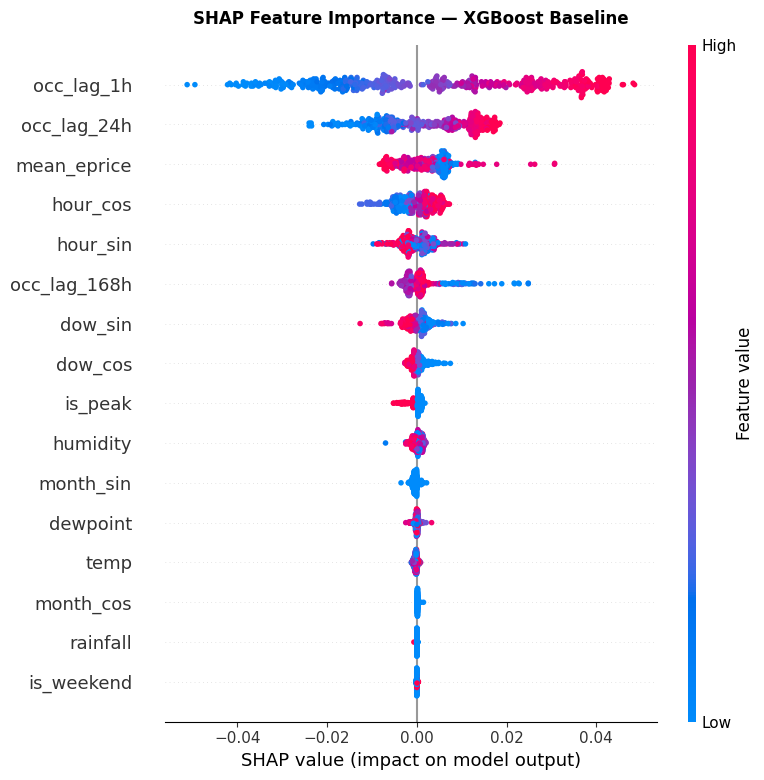

Saved: xgb_shap_summary.png

Feature importance (mean |SHAP|):
     feature  mean_shap
  occ_lag_1h   0.021942
 occ_lag_24h   0.009518
 mean_eprice   0.004709
    hour_cos   0.003204
    hour_sin   0.002481
occ_lag_168h   0.002456
     dow_sin   0.001856
     dow_cos   0.001092
     is_peak   0.000920
    humidity   0.000781
   month_sin   0.000498
    dewpoint   0.000316
        temp   0.000314
   month_cos   0.000160
    rainfall   0.000047
  is_weekend   0.000031


In [4]:
import xgboost as xgb
import shap

# ── Train XGBoost ─────────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=20,
    eval_metric='rmse',
    random_state=42,
    device='cuda'  # uses GPU T4
)

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_val_xgb, y_val_xgb)],
    verbose=100
)

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred_xgb = xgb_model.predict(X_test_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test_xgb, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test_xgb - y_pred_xgb) / (y_test_xgb + 1e-8))) * 100

print("=" * 40)
print("  XGBoost Baseline Results")
print("=" * 40)
print(f"  RMSE: {rmse_xgb:.6f}")
print(f"  MAE:  {mae_xgb:.6f}")
print(f"  MAPE: {mape_xgb:.2f}%")
print("=" * 40)

# ── SHAP feature importance ───────────────────────────────────────────────────
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_xgb)

# Summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_xgb, show=False)
plt.title('SHAP Feature Importance — XGBoost Baseline', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('xgb_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: xgb_shap_summary.png")

# Mean absolute SHAP values (ranked)
shap_df = pd.DataFrame({
    'feature':    X_test_xgb.columns,
    'mean_shap':  np.abs(shap_values).mean(axis=0)
}).sort_values('mean_shap', ascending=False)

print("\nFeature importance (mean |SHAP|):")
print(shap_df.to_string(index=False))

**ARIMA Baseline**

In [5]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
import time

# ── ARIMA on system-level mean occupancy ──────────────────────────────────────
# Use mean occupancy across all zones (system-level signal)
mean_occ_train = mean_occ_series.loc[occ_train.index]
mean_occ_test  = mean_occ_series.loc[occ_test.index]

# Stationarity check
adf_result = adfuller(mean_occ_train)
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
print(f"Stationary:    {'Yes' if adf_result[1] < 0.05 else 'No — differencing needed'}")

ADF Statistic: -6.0086
p-value:       0.0000
Stationary:    Yes


**Fitting ARIMA**

Fitting ARIMA(2,0,2)... this may take 1-2 minutes.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fitted in 3.6s
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3040
Model:                 ARIMA(2, 0, 2)   Log Likelihood                6720.671
Date:                Thu, 25 Jun 2026   AIC                         -13429.341
Time:                        20:42:38   BIC                         -13393.224
Sample:                    09-01-2022   HQIC                        -13416.359
                         - 01-05-2023                                         
Covariance Type:                  opg                                         

  ARIMA(2,0,2) Baseline Results
  RMSE: 0.058378
  MAE:  0.046003
  MAPE: nan%


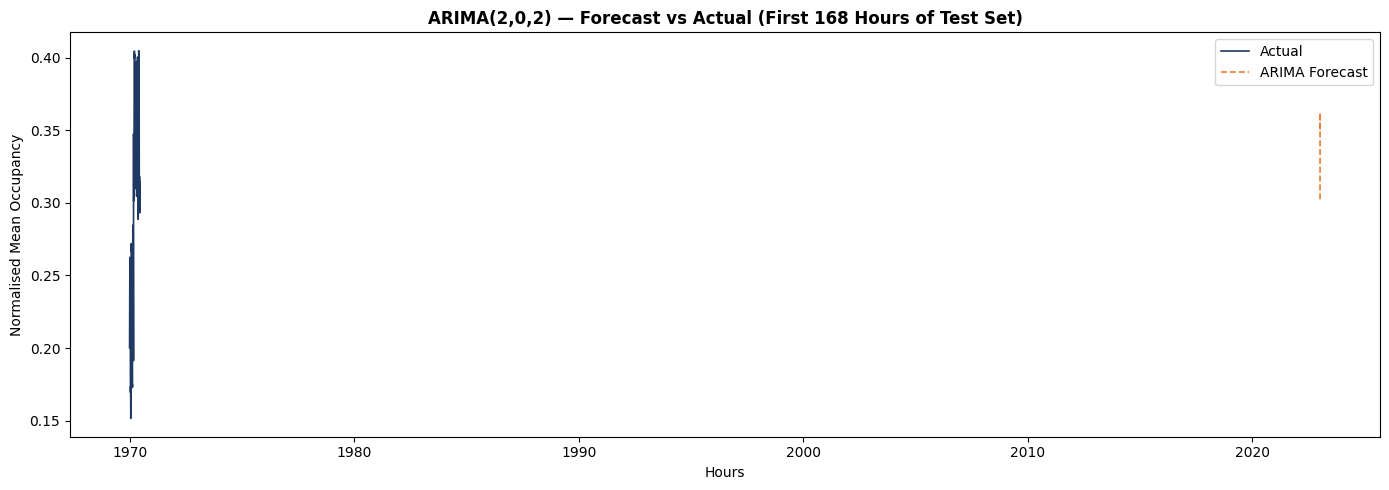

Saved: arima_forecast.png


In [6]:
# ── Fit ARIMA(2, 0, 2) ────────────────────────────────────────────────────────
# p=2 (autoregressive lags), d=0 (stationary), q=2 (moving average)
print("Fitting ARIMA(2,0,2)... this may take 1-2 minutes.")
start = time.time()

arima_model = ARIMA(mean_occ_train, order=(2, 0, 2)).fit()

print(f"Fitted in {time.time() - start:.1f}s")
print(arima_model.summary().tables[0])

# ── Forecast on test set ──────────────────────────────────────────────────────
arima_forecast = arima_model.forecast(steps=len(mean_occ_test))
arima_forecast = np.clip(arima_forecast, 0, 1)

rmse_arima = np.sqrt(mean_squared_error(mean_occ_test, arima_forecast))
mae_arima  = mean_absolute_error(mean_occ_test, arima_forecast)
mape_arima = np.mean(np.abs((mean_occ_test - arima_forecast) / (mean_occ_test + 1e-8))) * 100

print("\n" + "=" * 40)
print("  ARIMA(2,0,2) Baseline Results")
print("=" * 40)
print(f"  RMSE: {rmse_arima:.6f}")
print(f"  MAE:  {mae_arima:.6f}")
print(f"  MAPE: {mape_arima:.2f}%")
print("=" * 40)

# ── Plot forecast vs actual ───────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(mean_occ_test.values[:168], label='Actual', color='#1F3864', linewidth=1.2)
plt.plot(arima_forecast[:168],       label='ARIMA Forecast', color='#ED7D31',
         linewidth=1.2, linestyle='--')
plt.title('ARIMA(2,0,2) — Forecast vs Actual (First 168 Hours of Test Set)',
          fontweight='bold')
plt.xlabel('Hours')
plt.ylabel('Normalised Mean Occupancy')
plt.legend()
plt.tight_layout()
plt.savefig('arima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: arima_forecast.png")

**GRU Baseline**

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ── Check GPU ─────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Sequence dataset ──────────────────────────────────────────────────────────
SEQ_LEN  = 24   # use 24 hours of history to predict next hour
PRED_LEN = 1

class OccupancyDataset(Dataset):
    def __init__(self, occ_scaled, exog_df, seq_len=24):
        self.seq_len = seq_len
        # System-level mean occupancy as target
        self.target = torch.tensor(
            occ_scaled.mean(axis=1), dtype=torch.float32)
        # Features: exog + mean occupancy
        feat = exog_df.values.astype(np.float32)
        occ_feat = occ_scaled.mean(axis=1).astype(np.float32).reshape(-1,1)
        self.features = torch.tensor(
            np.concatenate([feat, occ_feat], axis=1), dtype=torch.float32)

    def __len__(self):
        return len(self.target) - self.seq_len

    def __getitem__(self, idx):
        x = self.features[idx : idx + self.seq_len]
        y = self.target[idx + self.seq_len]
        return x, y

# ── Create datasets ───────────────────────────────────────────────────────────
train_ds = OccupancyDataset(occ_train_scaled, exog_train)
val_ds   = OccupancyDataset(occ_val_scaled,   exog_val)
test_ds  = OccupancyDataset(occ_test_scaled,  exog_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")
print(f"Input features per timestep: {train_ds.features.shape[1]}")

Device: cuda
Train batches: 48
Val batches:   10
Test batches:  10
Input features per timestep: 14


In [8]:
# ── GRU model definition ──────────────────────────────────────────────────────
class GRUForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

# ── Instantiate ───────────────────────────────────────────────────────────────
INPUT_SIZE = train_ds.features.shape[1]
model = GRUForecaster(input_size=INPUT_SIZE).to(device)
print(f"GRU model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Training ──────────────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5)

EPOCHS    = 50
best_val  = float('inf')
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            val_loss += criterion(model(xb), yb).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), 'gru_best.pt')

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} — "
              f"Train: {train_loss:.6f}  Val: {val_loss:.6f}  "
              f"Best: {best_val:.6f}")

print(f"\nTraining complete. Best val loss: {best_val:.6f}")

GRU model parameters: 162,689
Epoch  10/50 — Train: 0.002076  Val: 0.003755  Best: 0.002635
Epoch  20/50 — Train: 0.001508  Val: 0.002971  Best: 0.002474
Epoch  30/50 — Train: 0.001402  Val: 0.003287  Best: 0.002474
Epoch  40/50 — Train: 0.001393  Val: 0.003008  Best: 0.002474
Epoch  50/50 — Train: 0.001324  Val: 0.003027  Best: 0.002474

Training complete. Best val loss: 0.002474


  GRU Baseline Results
  RMSE: 0.045728
  MAE:  0.033046
  MAPE: 10.44%


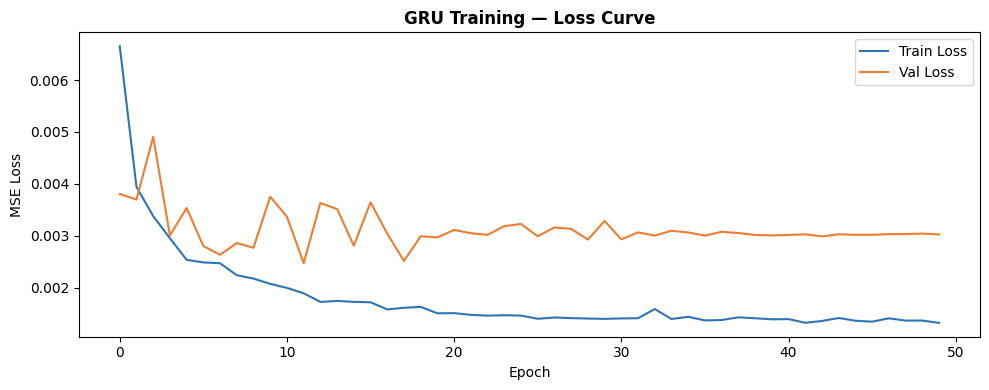

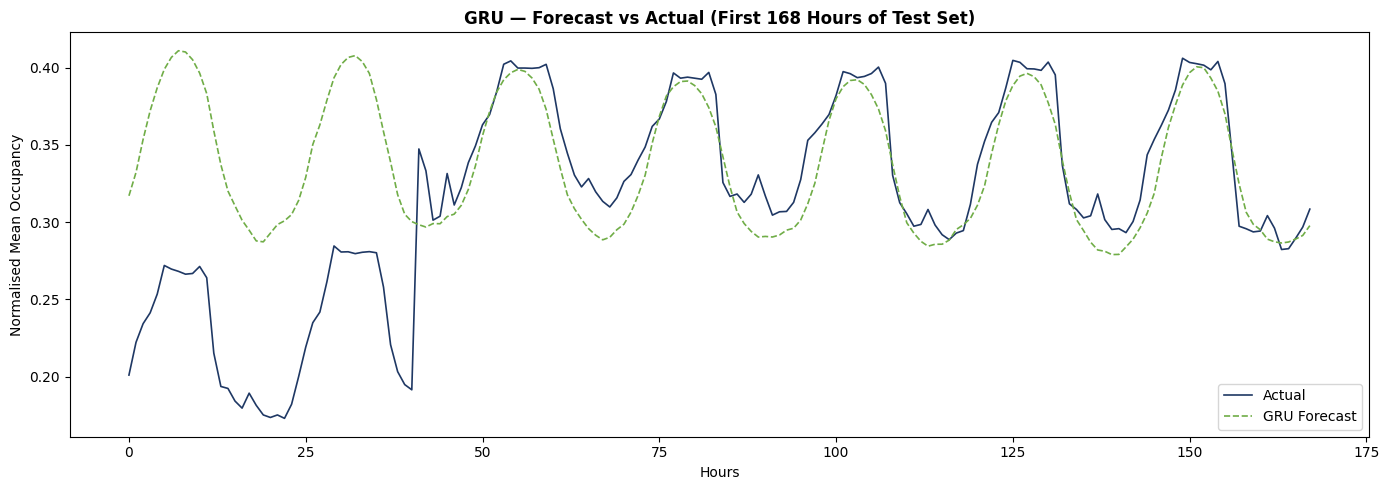

Saved: gru_loss_curve.png, gru_forecast.png


In [9]:
# ── Evaluate on test set ──────────────────────────────────────────────────────
model.load_state_dict(torch.load('gru_best.pt'))
model.eval()

preds, actuals = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds.extend(model(xb).cpu().numpy())
        actuals.extend(yb.numpy())

preds   = np.array(preds)
actuals = np.array(actuals)

rmse_gru = np.sqrt(mean_squared_error(actuals, preds))
mae_gru  = mean_absolute_error(actuals, preds)
mape_gru = np.mean(np.abs((actuals - preds) / (actuals + 1e-8))) * 100

print("=" * 40)
print("  GRU Baseline Results")
print("=" * 40)
print(f"  RMSE: {rmse_gru:.6f}")
print(f"  MAE:  {mae_gru:.6f}")
print(f"  MAPE: {mape_gru:.2f}%")
print("=" * 40)

# ── Loss curve ────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='#2E75B6')
plt.plot(val_losses,   label='Val Loss',   color='#ED7D31')
plt.title('GRU Training — Loss Curve', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('gru_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Forecast plot ─────────────────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(actuals[:168], label='Actual',       color='#1F3864', linewidth=1.2)
plt.plot(preds[:168],   label='GRU Forecast', color='#70AD47',
         linewidth=1.2, linestyle='--')
plt.title('GRU — Forecast vs Actual (First 168 Hours of Test Set)',
          fontweight='bold')
plt.xlabel('Hours')
plt.ylabel('Normalised Mean Occupancy')
plt.legend()
plt.tight_layout()
plt.savefig('gru_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gru_loss_curve.png, gru_forecast.png")